Código adaptado de:

[1] Sebastian Raschka,Yuxi (Hayden) Liu e e Vahid Mirjalili. Machine Learning with PyTorch and Scikit-Learn [(Github link)](https://github.com/rasbt/machine-learning-book). [capítulo 17]





# Laboratório 2A: GANs (RNA complemetamente conectada, imagens)

## Importações

In [1]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

In [4]:
print(f"torch.__version__: {torch.__version__}")

# tenta usar acelerador se disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

# Exibe qual dispositivo está sendo utilizado
print(f"Usando acelerador: {device}.")

torch.__version__: 2.13.0
Usando acelerador: mps.


## Síntese de novos dados

In [5]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_02.png', width=700)

## Geração de amostras com as GANs

In [6]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_03.png', width=700)

## Funções de perda no Gerador e Discriminador das GANs

- Saída do discriminador: probabilidade da entrada (imagem) ser **REAL**.

In [7]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_04.png', width=800)

## Implementação da GAN


In [8]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_08.png', width=600)

In [9]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_17.png', width=600)

In [10]:
image_size = (28, 28)        # Define o tamanho da imagem de saída (MNIST possui imagens de 28x28 pixels).
z_size = 20                  # Define o tamanho do vetor de ruído (dimensão do espaço latente usado pelo gerador).

gen_hidden_layers = 1        # Número de camadas ocultas no gerador.
gen_hidden_size = 100        # Número de neurônios na camada oculta do gerador.

disc_hidden_layers = 1       # Número de camadas ocultas no discriminador.
disc_hidden_size = 100       # Número de neurônios na camada oculta do discriminador.

torch.manual_seed(1)         # Fixa a semente para reprodutibilidade dos resultados gerados pelo PyTorch.

### Gerador

In [11]:
gen_model = nn.Sequential(                                     # Define o gerador como uma rede sequencial (camadas empilhadas).
    nn.Linear(z_size, gen_hidden_size),                        # Camada linear totalmente conectada: entrada de tamanho z_size, saída com gen_hidden_size neurônios.
    nn.LeakyReLU(),                                            # Função de ativação LeakyReLU, que evita o problema de "neurônios mortos".
    nn.Linear(gen_hidden_size, np.prod(image_size)),           # Camada linear: transforma para o número total de pixels da imagem (28*28 = 784).
    nn.Tanh()                                                  # Função de ativação Tanh: garante que os valores de saída fiquem na faixa [-1, 1].
)
print(gen_model)                                               # Exibe a arquitetura do gerador definida.
summary(gen_model, input_size=(1, z_size), device=device)      # Mostra um resumo detalhado da rede (torchinfo): camadas, parâmetros e shapes de entrada/saída.

Sequential(
  (0): Linear(in_features=20, out_features=100, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=100, out_features=784, bias=True)
  (3): Tanh()
)


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 784]                  --
├─Linear: 1-1                            [1, 100]                  2,100
├─LeakyReLU: 1-2                         [1, 100]                  --
├─Linear: 1-3                            [1, 784]                  79,184
├─Tanh: 1-4                              [1, 784]                  --
Total params: 81,284
Trainable params: 81,284
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.33
Estimated Total Size (MB): 0.33

### Discriminador

In [12]:
disc_model = nn.Sequential(                                      # Define o discriminador como uma rede sequencial.
    nn.Linear(np.prod(image_size), disc_hidden_size, bias=False),# Camada linear: entrada com o número total de pixels (28*28 = 784), saída com disc_hidden_size neurônios. Sem termo de bias.
    nn.LeakyReLU(),                                              # Função de ativação LeakyReLU para introduzir não-linearidade.
    nn.Dropout(p=0.5),                                           # Camada de dropout com probabilidade de 50%.
    nn.Linear(disc_hidden_size, 1),                              # Camada linear final que reduz para uma única saída escalar.
    nn.Sigmoid()                                                 # Função sigmoide: comprime a saída para [0,1], interpretada como probabilidade de ser real.
)
print(disc_model)                                                       # Exibe a arquitetura do discriminador definida.
summary(disc_model, input_size=(1, np.prod(image_size)), device=device) # Mostra um resumo da rede com torchinfo (camadas, parâmetros e shapes de entrada/saída).

Sequential(
  (0): Linear(in_features=784, out_features=100, bias=False)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=100, out_features=1, bias=True)
  (4): Sigmoid()
)


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 100]                  78,400
├─LeakyReLU: 1-2                         [1, 100]                  --
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 1]                    101
├─Sigmoid: 1-5                           [1, 1]                    --
Total params: 78,501
Trainable params: 78,501
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.31
Estimated Total Size (MB): 0.32

### Conjunto de treinamento

In [13]:
image_path = './data/'                                    # Define o diretório raiz onde o conjunto de dados MNIST será armazenado.

transform = transforms.Compose([                           # Define uma sequência de transformações a serem aplicadas às imagens do dataset.
    transforms.ToTensor(),                                 # Converte as imagens PIL em tensores PyTorch.
    transforms.Normalize(mean=(0.5), std=(0.5)),           # Normaliza os valores dos pixels para a faixa [-1, 1], com média 0.5 e desvio 0.5.
])

mnist_dataset = datasets.MNIST(root=image_path,            # Cria o objeto do dataset MNIST.
                               train=True,                 # Define que serão carregadas as imagens do conjunto de treinamento.
                               transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                               download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

example, label = next(iter(mnist_dataset))                 # Obtém o primeiro par (imagem, rótulo) do dataset MNIST.
print(f'Min: {example.min()} Max: {example.max()}')        # Exibe os valores mínimo e máximo do tensor da imagem (após normalização).
print(example.shape)                                       # Exibe o formato do tensor da imagem (para MNIST: [1, 28, 28]).

Min: -1.0 Max: 1.0
torch.Size([1, 28, 28])


In [14]:
def create_noise(batch_size, z_size, mode_z):               # Define a função create_noise para gerar vetores de ruído aleatório.
    if mode_z == 'uniform':                                 # Caso o modo de geração seja "uniform":
        input_z = torch.rand(batch_size, z_size)*2 - 1      # Gera amostras de ruído com distribuição uniforme em [-1, 1].
    elif mode_z == 'normal':                                # Caso o modo de geração seja "normal":
        input_z = torch.randn(batch_size, z_size)           # Gera amostras de ruído com distribuição normal padrão N(0,1).
    return input_z                                          # Retorna o lote de vetores de ruído gerados (tensor de shape [batch_size, z_size]).


### Treinamento da GAN

In [15]:
batch_size = 64                                           # Define o tamanho do mini-lote (número de amostras processadas por iteração).
mode_z = 'uniform'                                        # Define o modo de geração do ruído: 'uniform' (U[-1,1]) ou 'normal' (N(0,1)).
torch.manual_seed(1)                                      # Fixa a semente para gerar números aleatórios reprodutíveis no PyTorch.
np.random.seed(1)                                         # Fixa a semente para gerar números aleatórios reprodutíveis no NumPy.

## Preparação do conjunto de dados
mnist_dl = DataLoader(mnist_dataset,                      # Cria um DataLoader para o conjunto MNIST.
                      batch_size=batch_size,              # Cada lote terá 64 imagens.
                      shuffle=True,                       # Embaralha os dados a cada época.
                      drop_last=True)                     # Descarta o último lote se não atingir o tamanho definido (64 imagens).

## Função de perda e otimizadores
loss_fn = nn.BCELoss()                                    # Define a função de perda: entropia cruzada binária (BCE: Binary Cross-Entropy).
g_optimizer = torch.optim.Adam(gen_model.parameters())    # Define o otimizador Adam para atualizar os parâmetros do gerador.
d_optimizer = torch.optim.Adam(disc_model.parameters())   # Define o otimizador Adam para atualizar os parâmetros do discriminador.

#### Treinamento do discriminador

In [16]:
def d_train(x):                                                 # Define a função d_train para treinar o discriminador em um lote de dados.
    disc_model.zero_grad()                                      # Zera os gradientes acumulados do discriminador para evitar acúmulo entre iterações.

    # Treinamento do discriminador com um lote real
    batch_size = x.size(0)                                      # Obtém o tamanho do lote (número de amostras).
    x = x.view(batch_size, -1).to(device)                       # Redimensiona as imagens para vetores (batch_size, 784) e envia para o dispositivo.
    d_labels_real = torch.ones(batch_size, 1, device=device)    # Cria rótulos: 1 para amostras reais.

    d_proba_real = disc_model(x)                                # Passa as imagens reais pelo discriminador e obtém probabilidades de serem reais.
    d_loss_real = loss_fn(d_proba_real, d_labels_real)          # Calcula a perda do discriminador para o lote real.

    # Treinamento do discriminador com um lote falso
    input_z = create_noise(batch_size, z_size, mode_z).to(device) # Gera ruído aleatório e envia para o dispositivo.
    g_output = gen_model(input_z)                                 # O gerador produz imagens falsas a partir do ruído.

    d_proba_fake = disc_model(g_output)                         # Passa as imagens falsas pelo discriminador e obtém probabilidades de serem reais.
    d_labels_fake = torch.zeros(batch_size, 1, device=device)   # Cria rótulos: 0 para as amostras geradas.
    d_loss_fake = loss_fn(d_proba_fake, d_labels_fake)          # Calcula a perda do discriminador para o lote falso.

    # Retropropagação do gradiente e atualização dos parâmetros do discriminador
    d_loss = d_loss_real + d_loss_fake                          # Combina as perdas do lote real e falso.
    d_loss.backward()                                           # Propaga os gradientes da perda total.
    d_optimizer.step()                                          # Atualiza os parâmetros do discriminador.

    # Retorna a perda e as probabilidades previstas para análise
    return d_loss.item(), d_proba_real.detach(), d_proba_fake.detach()

#### Treinamento do gerador

In [17]:
def g_train(x):                                              # Define a função g_train para treinar o gerador em um lote.
    gen_model.zero_grad()                                    # Zera os gradientes acumulados do gerador.

    batch_size = x.size(0)                                          # Obtém o tamanho do lote.
    input_z = create_noise(batch_size, z_size, mode_z).to(device)   # Gera ruído aleatório e envia para o dispositivo.
    g_labels_real = torch.ones(batch_size, 1, device=device)        # Define rótulos 1, pois o objetivo é que o D classifique as amostras geradas como reais.

    g_output = gen_model(input_z)                            # Produz amostras falsas a partir do ruído via gerador.
    d_proba_fake = disc_model(g_output)                      # Avalia as amostras geradas no discriminador.
    g_loss = loss_fn(d_proba_fake, g_labels_real)            # Calcula a perda do gerador comparando com rótulos 1.

    # Retropropagação do gradiente e atualização somente dos parâmetros do gerador
    g_loss.backward()                                        # Propaga os gradientes no grafo do gerador.
    g_optimizer.step()                                       # Atualiza os pesos do gerador.

    return g_loss.item()                                     # Retorna a perda.

#### Função auxiliar para gerar amostras a partir do gerador.

In [18]:
def create_samples(g_model, input_z):
    g_output = g_model(input_z)                                  # Executa o gerador no ruído de entrada.
    images = torch.reshape(g_output, (batch_size, *image_size))  # Remodela para o formato de imagem (batch_size, 28, 28).
    return (images + 1) / 2.0                                    # Reescala de [-1, 1] para [0, 1] (compatível com visualização).

In [19]:
fixed_z = create_noise(batch_size, z_size, mode_z).to(device)    # Ruído fixo para monitorar a evolução do gerador ao longo das épocas.

epoch_samples = []                                               # Lista para armazenar amostras geradas em épocas selecionadas.
all_d_losses = []                                                # Histórico da perda média do discriminador por época.
all_g_losses = []                                                # Histórico da perda média do gerador por época.
all_d_real = []                                                  # Histórico da saída média do discriminador para imagens reais por época.
all_d_fake = []                                                  # Histórico da saída média do discriminador para imagens falsas por época.

num_epochs = 100                                                 # Número total de épocas de treinamento.
torch.manual_seed(1)                                             # Fixa a semente para reprodutibilidade dos resultados.

for epoch in range(1, num_epochs + 1):                           # Loop principal de treinamento por época.
    d_losses, g_losses = [], []                                  # Listas temporárias para perdas por mini-lote na época atual.
    d_vals_real, d_vals_fake = [], []                            # Listas temporárias para saídas médias do discriminador em cada mini-lote.

    for i, (x, _) in enumerate(mnist_dl):                        # Itera sobre os mini-lotes do DataLoader.
        d_loss, d_proba_real, d_proba_fake = d_train(x)          # Treina o discriminador no mini-lote e obtém saídas.
        d_losses.append(d_loss)                                  # Registra a perda do discriminador no mini-lote.
        g_losses.append(g_train(x))                              # Treina o gerador no mini-lote e registra a perda.

        d_vals_real.append(d_proba_real.mean().cpu())            # Registra a média das probabilidades do discriminador para dados reais.
        d_vals_fake.append(d_proba_fake.mean().cpu())            # Registra a média das probabilidades do discriminador para dados falsos.

    all_d_losses.append(torch.tensor(d_losses).mean())           # Média das perdas do discriminador na época.
    all_g_losses.append(torch.tensor(g_losses).mean())           # Média das perdas do gerador na época.
    all_d_real.append(torch.tensor(d_vals_real).mean())          # Média das saídas do discriminador em amostras reais na época.
    all_d_fake.append(torch.tensor(d_vals_fake).mean())          # Média das saídas do discriminador em amostras falsas na época.

    print(f'Epoch {epoch:03d} | Avg Losses >>'                   # Imprime um resumo compacto da época.
          f' G/D {all_g_losses[-1]:.4f}/{all_d_losses[-1]:.4f}'
          f' [D-Real: {all_d_real[-1]:.4f} D-Fake: {all_d_fake[-1]:.4f}]')

    epoch_samples.append(create_samples(gen_model, fixed_z).detach().cpu().numpy()) # Armazena um lote de amostras geradas com ruído fixo para comparação.

Epoch 001 | Avg Losses >> G/D 0.9096/0.8543 [D-Real: 0.8411 D-Fake: 0.4726]
Epoch 002 | Avg Losses >> G/D 0.9341/1.1338 [D-Real: 0.6187 D-Fake: 0.4354]
Epoch 003 | Avg Losses >> G/D 0.9450/1.1798 [D-Real: 0.5854 D-Fake: 0.4249]
Epoch 004 | Avg Losses >> G/D 0.9585/1.1909 [D-Real: 0.5876 D-Fake: 0.4199]
Epoch 005 | Avg Losses >> G/D 0.9114/1.2297 [D-Real: 0.5689 D-Fake: 0.4313]
Epoch 006 | Avg Losses >> G/D 0.9046/1.2661 [D-Real: 0.5549 D-Fake: 0.4425]
Epoch 007 | Avg Losses >> G/D 0.9102/1.2601 [D-Real: 0.5571 D-Fake: 0.4391]
Epoch 008 | Avg Losses >> G/D 0.8318/1.3040 [D-Real: 0.5377 D-Fake: 0.4575]
Epoch 009 | Avg Losses >> G/D 0.9217/1.2446 [D-Real: 0.5625 D-Fake: 0.4354]
Epoch 010 | Avg Losses >> G/D 1.0376/1.1648 [D-Real: 0.5962 D-Fake: 0.4006]
Epoch 011 | Avg Losses >> G/D 1.1125/1.1150 [D-Real: 0.6189 D-Fake: 0.3859]
Epoch 012 | Avg Losses >> G/D 0.9921/1.1894 [D-Real: 0.5897 D-Fake: 0.4124]
Epoch 013 | Avg Losses >> G/D 0.9785/1.1952 [D-Real: 0.5879 D-Fake: 0.4151]
Epoch 014 | 

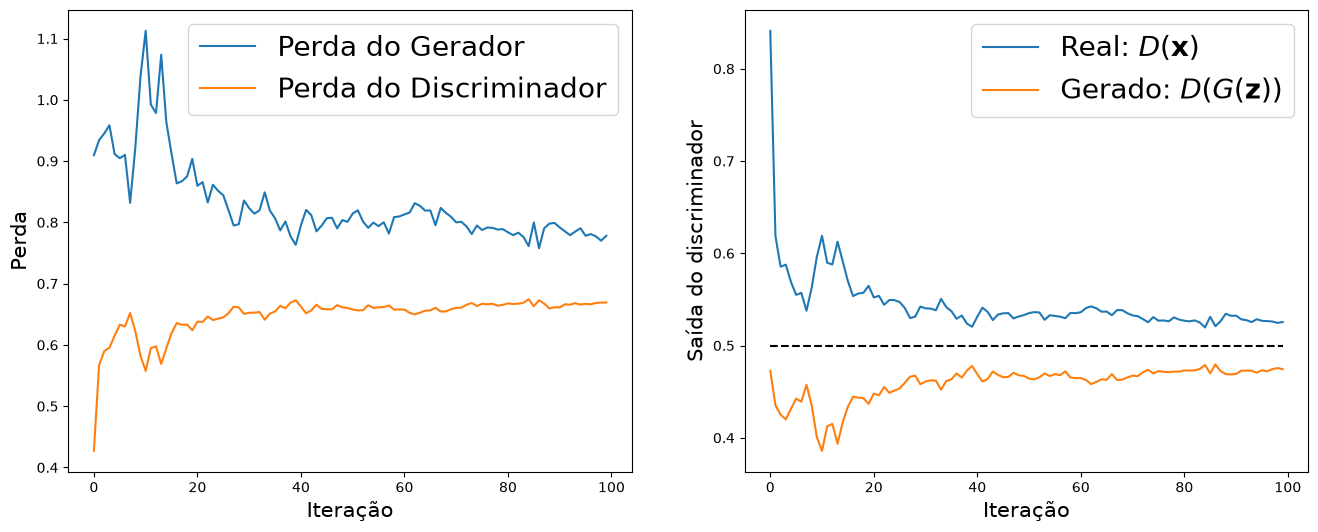

In [20]:
fig = plt.figure(figsize=(16, 6))                           # Cria uma figura.

## Plotando as perdas (Generator e Discriminator)
ax = fig.add_subplot(1, 2, 1)                                   # Adiciona o primeiro subplot (linha 1, coluna 2, posição 1).

plt.plot(all_g_losses, label='Perda do Gerador')                # Plota a curva da perda média do gerador ao longo das épocas.
half_d_losses = [all_d_loss/2 for all_d_loss in all_d_losses]
plt.plot(half_d_losses, label='Perda do Discriminador')         # Plota a curva da perda média do discriminador.
plt.legend(fontsize=20)                                         # Exibe a legenda dos gráficos com fonte maior (tamanho 20).
ax.set_xlabel('Iteração', size=15)                              # Define o rótulo do eixo X como "Iteração".
ax.set_ylabel('Perda', size=15)                                 # Define o rótulo do eixo Y como "Perda".

## Plotando as saídas médias do discriminador
ax = fig.add_subplot(1, 2, 2)                                   # Adiciona o segundo subplot (linha 1, coluna 2, posição 2).
plt.plot(all_d_real, label=r'Real: $D(\mathbf{x})$')            # Plota a saída média do discriminador para imagens reais.
plt.plot(all_d_fake, label=r'Gerado: $D(G(\mathbf{z}))$')       # Plota a saída média do discriminador para imagens falsas.
plt.plot([0, len(all_d_real)-1], [0.5, 0.5], 'k--', label='')
plt.legend(fontsize=20)                                         # Exibe a legenda dos gráficos com fonte maior (tamanho 20).
ax.set_xlabel('Iteração', size=15)                              # Define o rótulo do eixo X como "Iteração".
ax.set_ylabel('Saída do discriminador', size=15)                # Define o rótulo do eixo Y como "Saída do discriminador".
plt.show()                                                      # Exibe a figura na tela.

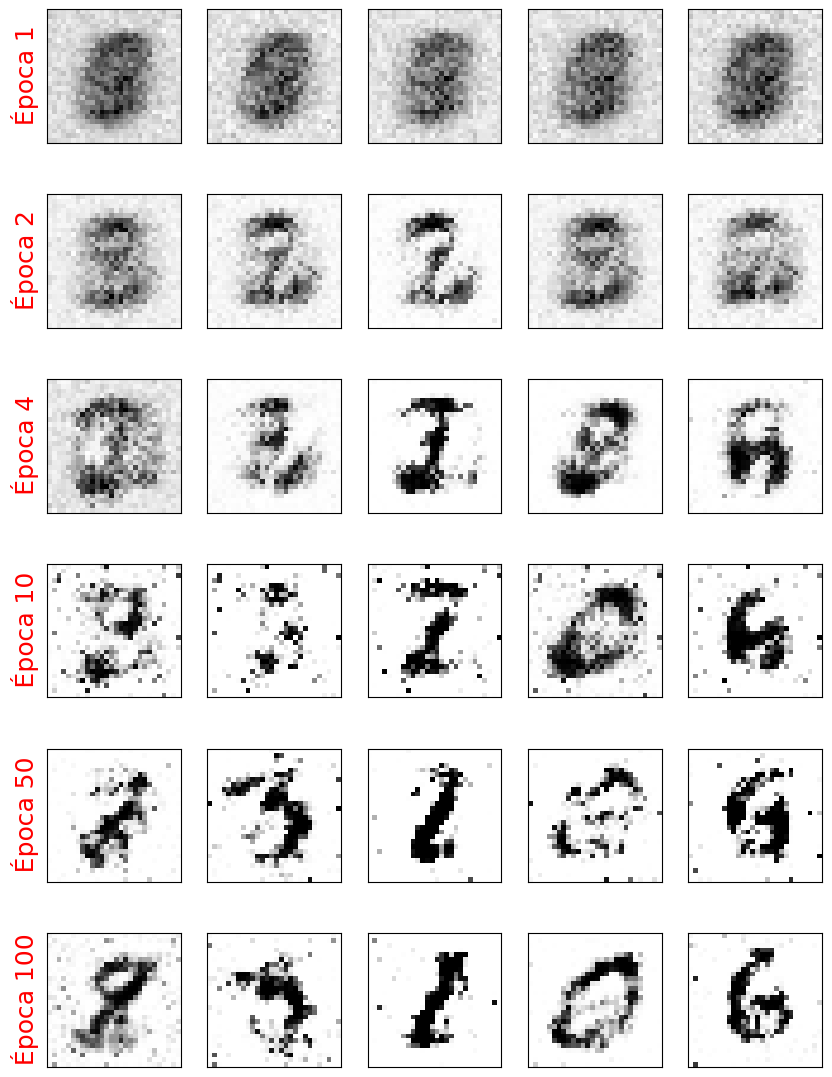

In [21]:
selected_epochs = [1, 2, 4, 10, 50, 100]                  # Lista de épocas selecionadas para visualização das amostras geradas.
fig = plt.figure(figsize=(10, 14))                        # Cria uma figura.

for i, e in enumerate(selected_epochs):                    # Itera sobre os índices e valores das épocas escolhidas.
    for j in range(5):                                     # Para cada época, seleciona 5 imagens geradas para exibir.
        ax = fig.add_subplot(6, 5, i*5 + j + 1)            # Cria um subplot na posição correspondente em uma grade 6x5.
        ax.set_xticks([])                                  # Remove os ticks do eixo X.
        ax.set_yticks([])                                  # Remove os ticks do eixo Y.

        if j == 0:                                         # Se for a primeira imagem da linha (coluna 0),
            ax.text(                                       # Adiciona um rótulo vertical indicando a época.
                -0.06, 0.5, f'Época {e}',                  # Texto indicando a época correspondente.
                rotation=90, size=18, color='red',         # Rotacionado em 90 graus, fonte maior e cor vermelha.
                horizontalalignment='right',               # Alinhamento horizontal à direita.
                verticalalignment='center',                # Alinhamento vertical centralizado.
                transform=ax.transAxes)                    # Usa coordenadas relativas ao eixo.

        image = epoch_samples[e-1][j]                      # Seleciona a j-ésima imagem gerada na época e.
        ax.imshow(image, cmap='gray_r')                    # Exibe a imagem em escala de cinza invertida (fundo branco, traços escuros).

plt.show()                                                 # Exibe a figura com todas as imagens.
